# Prepared Dataset Exploration (HAM10000)

This notebook explores class balance in the prepared metadata using bar charts for:
- `Stage 1`
- `Stage 2`
- `Stage 3`


In [113]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path("..").resolve()
META_PATH = PROJECT_ROOT / "data" / "prepared" / "metadata.csv"

metadata = pd.read_csv(META_PATH)

display_cols = [
    "isic_id",
    "lesion_id",
    "age_approx",
    "sex",
    "anatom_site_general",
    "melanocytic",
    "Stage 1",
    "Stage 2",
]

styled = (
    metadata[display_cols]
    .sample(n=10, random_state=49)
    .style
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]}
    ])
)

display(styled)


,isic_id,lesion_id,age_approx,sex,anatom_site_general,melanocytic,Stage 1,Stage 2
1424,ISIC_0025730,IL_1213599,30.000000,male,posterior torso,True,benign,nv
9968,ISIC_0034274,IL_6752385,30.000000,female,anterior torso,True,benign,nv
1289,ISIC_0025595,IL_0226003,45.000000,female,upper extremity,True,benign,nv
1819,ISIC_0026125,IL_5716524,20.000000,female,lower extremity,True,benign,nv
3073,ISIC_0027379,IL_9244814,70.000000,male,anterior torso,True,benign,nv
809,ISIC_0025115,IL_9517350,30.000000,male,upper extremity,True,benign,nv
333,ISIC_0024639,IL_6087426,60.000000,male,posterior torso,True,benign,nv
659,ISIC_0024965,IL_2034371,60.000000,male,oral/genital,True,benign,nv
4351,ISIC_0028657,IL_0562195,70.000000,male,lower extremity,True,benign,nv
9428,ISIC_0033734,IL_0621333,60.000000,female,posterior torso,True,benign,nv


In [102]:
def bar_counts(dataframe, column, title, color="steelblue", figsize=(8, 4), ylim_factor=1.12):
    counts = dataframe[column].fillna("(NaN)").value_counts(dropna=False).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(range(len(counts)), counts.values, color=color)

    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index.astype(str), rotation=45, ha="right")
    ax.set_title(title)
    ax.set_ylabel("Image count")
    ax.set_xlabel("Class")

    y_max = counts.max() if len(counts) else 1
    ax.set_ylim(0, y_max * ylim_factor)

    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(val),
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()

    return counts


def styled_counts_table(counts, label_name):
    counts_df = counts.rename_axis(label_name).reset_index(name="Image count")

    # Add total row
    total_row = pd.DataFrame({
        label_name: ["Total"],
        "Image count": [counts_df["Image count"].sum()]
    })

    counts_df = pd.concat([counts_df, total_row], ignore_index=True)

    def highlight_total(row):
        if row[label_name] == "Total":
            return ["font-weight: bold"] * len(row)
        return [""] * len(row)

    return (
        counts_df.style
        .apply(highlight_total, axis=1)
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "left")]}
        ])
        .hide(axis="index")
    )


## Stage 1 Distribution

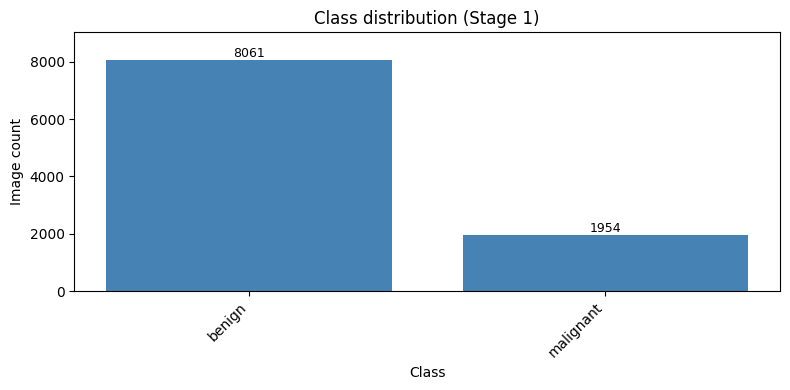

Stage 1,Image count
benign,8061
malignant,1954
Total,10015


In [103]:
stage1_counts = bar_counts(
    metadata,
    "Stage 1",
    "Class distribution (Stage 1)",
    color="steelblue",
    figsize=(8, 4),
    ylim_factor=1.12,
)
display(styled_counts_table(stage1_counts, "Stage 1"))


## Stage 2 Distribution

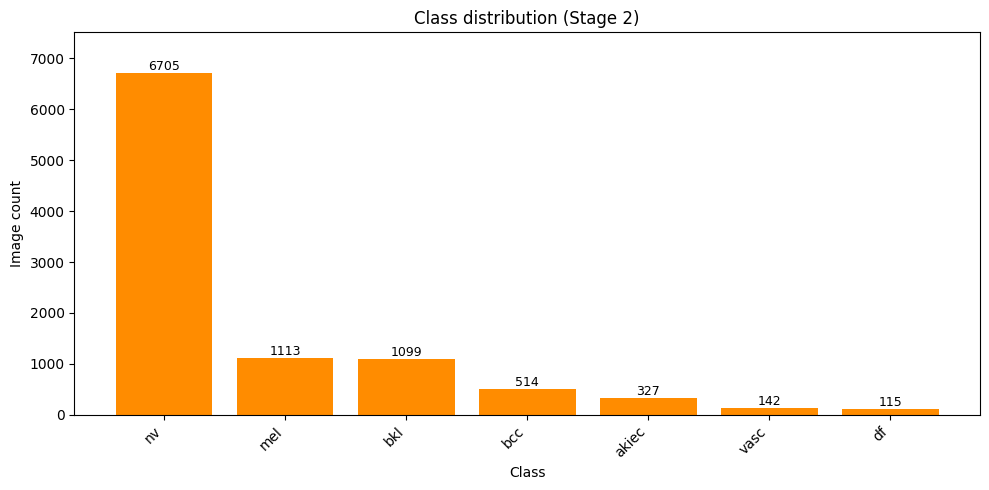

Stage 2,Image count
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115
Total,10015


In [104]:
stage2_counts = bar_counts(
    metadata,
    "Stage 2",
    "Class distribution (Stage 2)",
    color="darkorange",
    figsize=(10, 5),
    ylim_factor=1.12,
)
display(styled_counts_table(stage2_counts, "Stage 2"))


## Hierarchy Sketch

Visual sketch of class flow: `Stage 1 -> Stage 2` (edge labels = image counts).
Nodes are automatically sorted to minimize edge crossings.


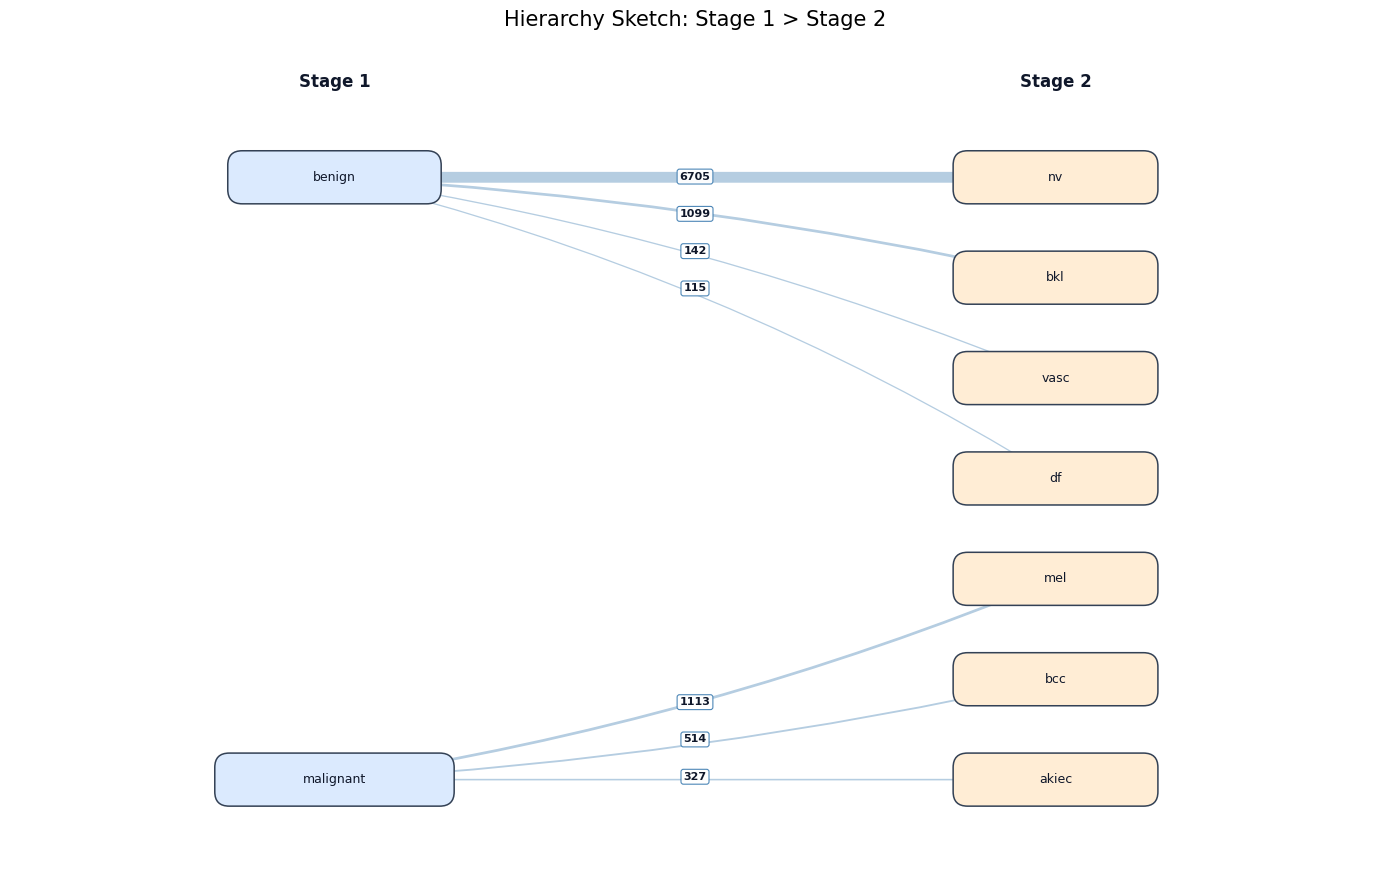

In [105]:

import textwrap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

stage_cols = ["Stage 1", "Stage 2"]
plot_df = metadata[stage_cols].fillna("(NaN)")

# Edge counts first
s1_s2 = (
    plot_df.groupby(["Stage 1", "Stage 2"], dropna=False)
    .size()
    .reset_index(name="count")
)

if s1_s2.empty:
    raise ValueError("No Stage 1/Stage 2 data available to plot.")

# Stage 1 order (most frequent first)
stage1_order = (
    plot_df["Stage 1"]
    .value_counts(dropna=False)
    .sort_values(ascending=False)
    .index
    .tolist()
)

stage1_rank = {label: i for i, label in enumerate(stage1_order)}
layout_df = s1_s2.copy()
layout_df["source_rank"] = layout_df["Stage 1"].map(stage1_rank).astype(float)
layout_df["weighted_rank"] = layout_df["source_rank"] * layout_df["count"]

stage2_order = (
    layout_df.groupby("Stage 2", as_index=False)
    .agg(
        total_count=("count", "sum"),
        weighted_rank_sum=("weighted_rank", "sum"),
    )
    .assign(barycenter=lambda d: d["weighted_rank_sum"] / d["total_count"])
    .sort_values(["barycenter", "total_count", "Stage 2"], ascending=[True, False, True])
    ["Stage 2"]
    .tolist()
)

layer_values = {"Stage 1": stage1_order, "Stage 2": stage2_order}

# Layer positions
x_pos = {"Stage 1": 0.0, "Stage 2": 1.0}
y_pos = {}
for col in stage_cols:
    vals = layer_values[col]
    n = len(vals)
    ys = np.linspace(0.92, 0.08, n) if n > 1 else np.array([0.5])
    y_pos[col] = {v: float(y) for v, y in zip(vals, ys)}

max_edge = s1_s2["count"].max()
fig, ax = plt.subplots(figsize=(14, 9))


def draw_edge_block(df, left_col, right_col, color, label_x):
    if df.empty:
        return

    edges = df.copy()
    edges["y1"] = edges[left_col].map(lambda v: y_pos[left_col][v])
    edges["y2"] = edges[right_col].map(lambda v: y_pos[right_col][v])

    edges = edges.sort_values([left_col, "y2"], ascending=[True, False]).reset_index(drop=True)
    edges["src_rank"] = edges.groupby(left_col).cumcount() + 1
    edges["src_n"] = edges.groupby(left_col)[right_col].transform("count")
    edges["y_offset"] = (edges["src_rank"] - (edges["src_n"] + 1) / 2) * 0.018

    for _, r in edges.iterrows():
        x1, y1 = x_pos[left_col], float(r["y1"])
        x2, y2 = x_pos[right_col], float(r["y2"])
        count = int(r["count"])

        lw = 0.8 + 7.0 * (count / max_edge)
        rad = 0.14 * np.sign(y2 - y1) * min(abs(y2 - y1) + 0.15, 1.0)

        edge = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-",
            connectionstyle=f"arc3,rad={rad}",
            linewidth=lw,
            color=color,
            alpha=0.40,
            zorder=1,
        )
        ax.add_patch(edge)

        t = (label_x - x1) / (x2 - x1)
        branch_offset = 0.028 if y1 >= 0.5 else -0.014
        y_lbl = y1 + t * (y2 - y1) + branch_offset + float(r["y_offset"])

        ax.text(
            label_x,
            y_lbl,
            str(count),
            fontsize=8,
            fontweight="bold",
            color="#0f172a",
            ha="center",
            va="center",
            zorder=4,
            bbox={
                "boxstyle": "round,pad=0.22",
                "facecolor": "#ffffff",
                "edgecolor": color,
                "linewidth": 0.8,
                "alpha": 0.96,
            },
        )


# Draw edges
draw_edge_block(s1_s2, "Stage 1", "Stage 2", color="steelblue", label_x=0.50)

# Draw nodes
node_colors = {"Stage 1": "#dbeafe", "Stage 2": "#ffedd5"}

for col in stage_cols:
    for v in layer_values[col]:
        x = x_pos[col]
        y = y_pos[col][v]

        label_raw = str(v)
        label_wrapped = textwrap.fill(label_raw, width=16, break_long_words=False)
        lines = label_wrapped.split("\n")
        n_lines = len(lines)
        max_len = max(len(line) for line in lines) if lines else len(label_raw)

        box_w = float(np.clip(0.20 + 0.012 * max_len, 0.26, 0.52))
        box_h = float(np.clip(0.05 + 0.024 * (n_lines - 1), 0.05, 0.18))
        font_size = 9 if max_len <= 16 else (8 if max_len <= 22 else 7)

        rect = FancyBboxPatch(
            (x - box_w / 2, y - box_h / 2),
            box_w,
            box_h,
            boxstyle="round,pad=0.012,rounding_size=0.02",
            linewidth=1.1,
            edgecolor="#334155",
            facecolor=node_colors[col],
            zorder=2,
        )
        ax.add_patch(rect)

        ax.text(
            x,
            y,
            label_wrapped,
            ha="center",
            va="center",
            fontsize=font_size,
            color="#0f172a",
            zorder=3,
            linespacing=1.1,
        )

# Layer titles
for col in stage_cols:
    ax.text(
        x_pos[col],
        1.04,
        col,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color="#0f172a",
    )

ax.set_xlim(-0.45, 1.45)
ax.set_ylim(-0.06, 1.10)
ax.axis("off")
ax.set_title("Hierarchy Sketch: Stage 1 > Stage 2", fontsize=15, pad=16)
plt.tight_layout()
plt.show()
